In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [4]:
df = pd.read_csv("Churn_Modelling.csv")

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [9]:
df.shape

(10000, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [10]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [11]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [12]:
df.describe(include='object')

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


In [13]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


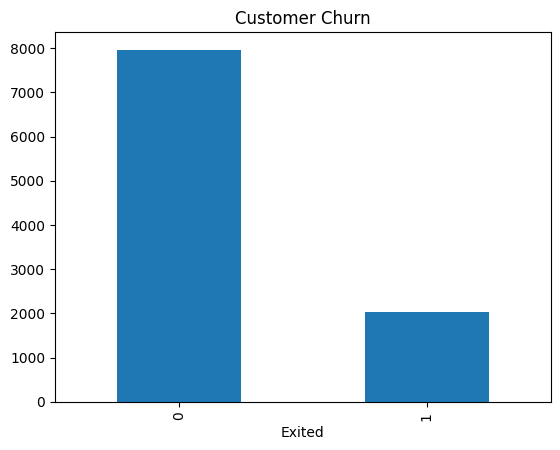

In [18]:
df['Exited'].value_counts().plot(kind='bar')
plt.title("Customer Churn")
plt.show()

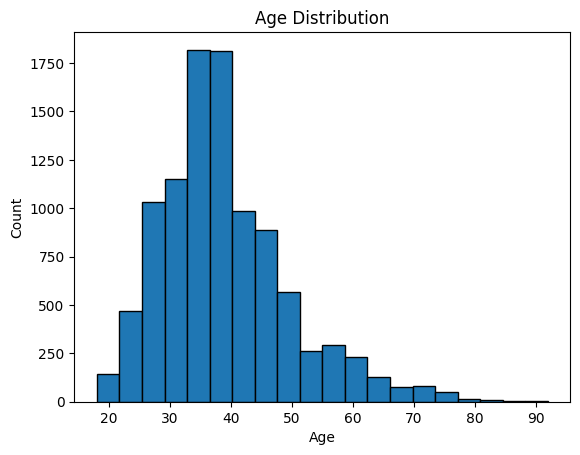

In [20]:
plt.hist(df['Age'], bins=20,edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

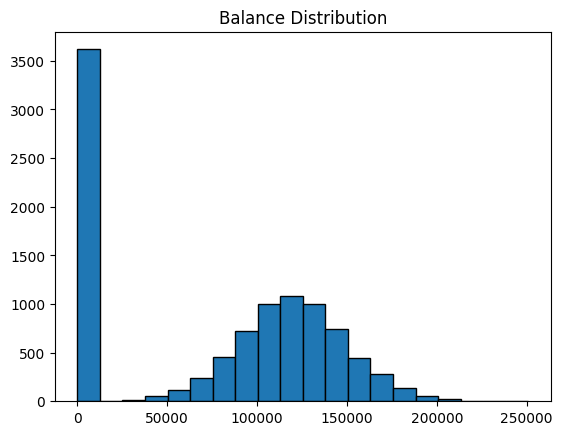

In [23]:
plt.hist(df['Balance'], bins=20,edgecolor='black')
plt.title("Balance Distribution")
plt.show()

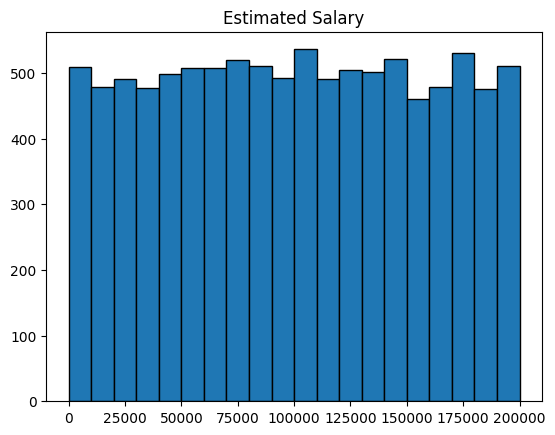

In [24]:
plt.hist(df['EstimatedSalary'], bins=20,edgecolor='black')
plt.title("Estimated Salary")
plt.show()

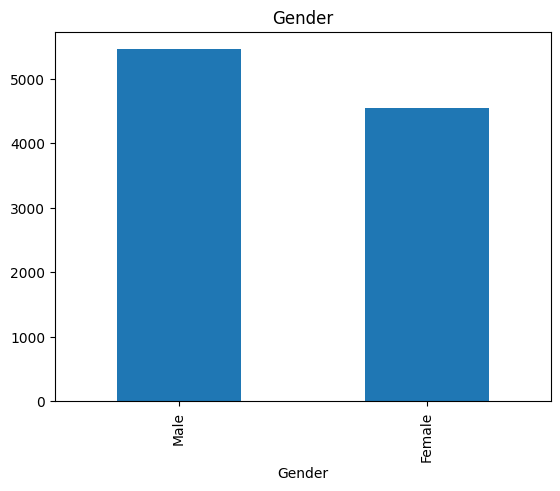

In [25]:
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender")
plt.show()

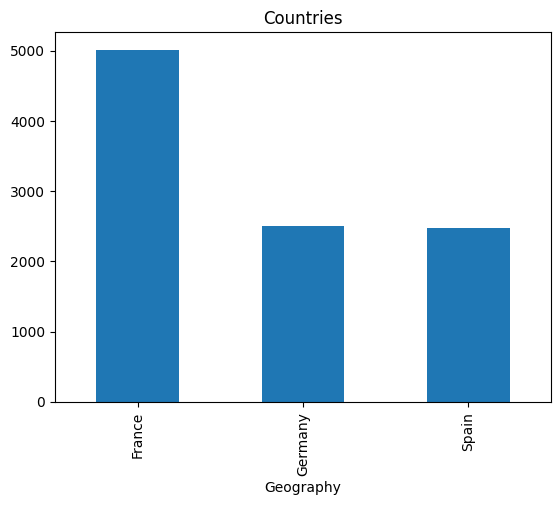

In [26]:
df['Geography'].value_counts().plot(kind='bar')
plt.title("Countries")
plt.show()

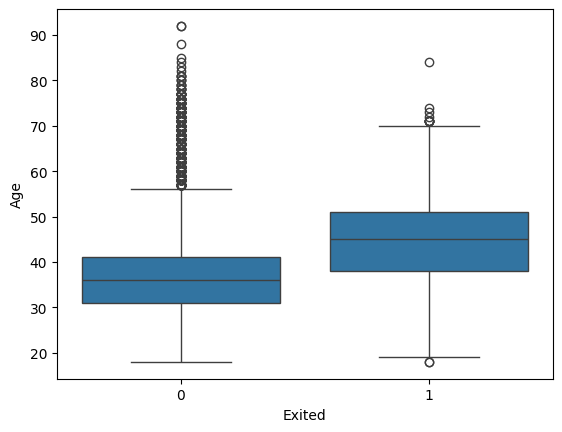

In [27]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.show()

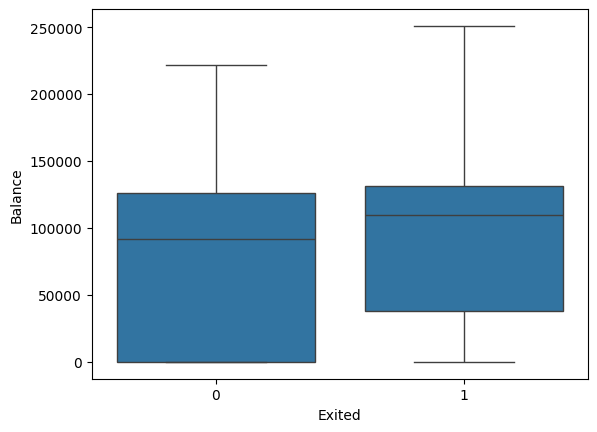

In [28]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.show()

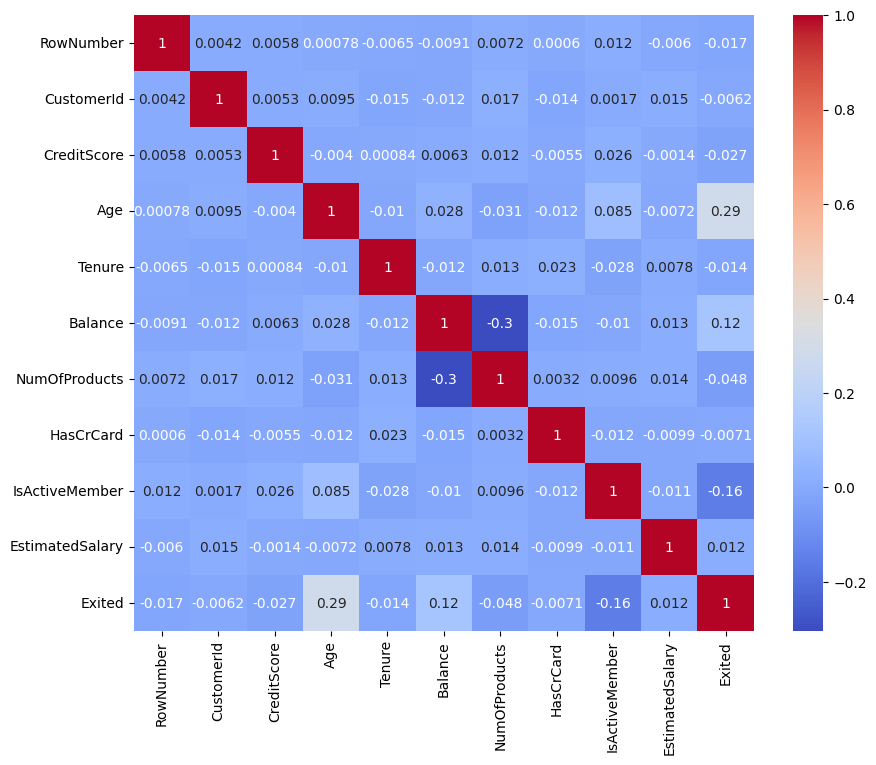

In [29]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [30]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [31]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [32]:
X.dtypes

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


In [33]:
X = pd.get_dummies(X, drop_first=True)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


In [59]:

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by="Accuracy", ascending=False, inplace=True)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8665,0.7625,0.4656,0.5782,0.8653
1,SVM,0.8560,0.7692,0.3817,0.5102,0.8248
2,KNN,0.8300,0.6109,0.3715,0.4620,0.7604
3,Logistic Regression,0.8110,0.5524,0.2010,0.2948,0.7789
4,Decision Tree,0.7810,0.4490,0.5038,0.4748,0.6763


In [70]:

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    results.append({
        "Model": name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Difference": round(train_acc - test_acc, 4)
    })

pd.DataFrame(results)

,Model,Train Accuracy,Test Accuracy,Difference
0,Logistic Regression,0.8114,0.8110,0.0004
1,Decision Tree,1.0000,0.7810,0.2190
2,Random Forest,1.0000,0.8665,0.1335
3,KNN,0.8741,0.8300,0.0441
4,SVM,0.8654,0.8560,0.0094


In [71]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [72]:
from sklearn.metrics import accuracy_score

rf_tuned_pred = rf_tuned.predict(X_test)

accuracy = accuracy_score(y_test, rf_tuned_pred)

print("Accuracy after tuning:", round(accuracy, 4))

Accuracy after tuning: 0.861


In [79]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, rf_tuned.predict(X_train))
test_acc = accuracy_score(y_test, rf_tuned.predict(X_test))

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)
print("Difference:", train_acc - test_acc)

Train Accuracy: 0.894375
Test Accuracy : 0.861
Difference: 0.033375000000000044


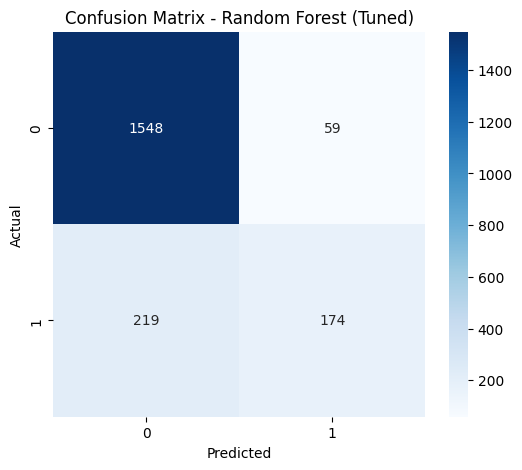

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_tuned_pred = rf_tuned.predict(X_test)

cm = confusion_matrix(y_test, rf_tuned_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - Random Forest (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [81]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_tuned_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.44      0.56       393

    accuracy                           0.86      2000
   macro avg       0.81      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000



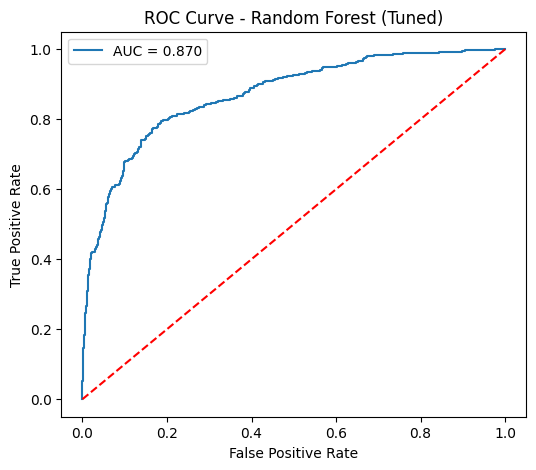

In [82]:
from sklearn.metrics import roc_curve, roc_auc_score

rf_tuned_prob = rf_tuned.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_tuned_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, rf_tuned_prob):.3f}")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (Tuned)")
plt.legend()

plt.show()

In [83]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_tuned.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
1,Age,0.322910
4,NumOfProducts,0.236387
3,Balance,0.102754
7,EstimatedSalary,0.074711
0,CreditScore,0.074278
6,IsActiveMember,0.068585
8,Geography_Germany,0.044658
2,Tenure,0.039685
10,Gender_Male,0.018440
5,HasCrCard,0.009581


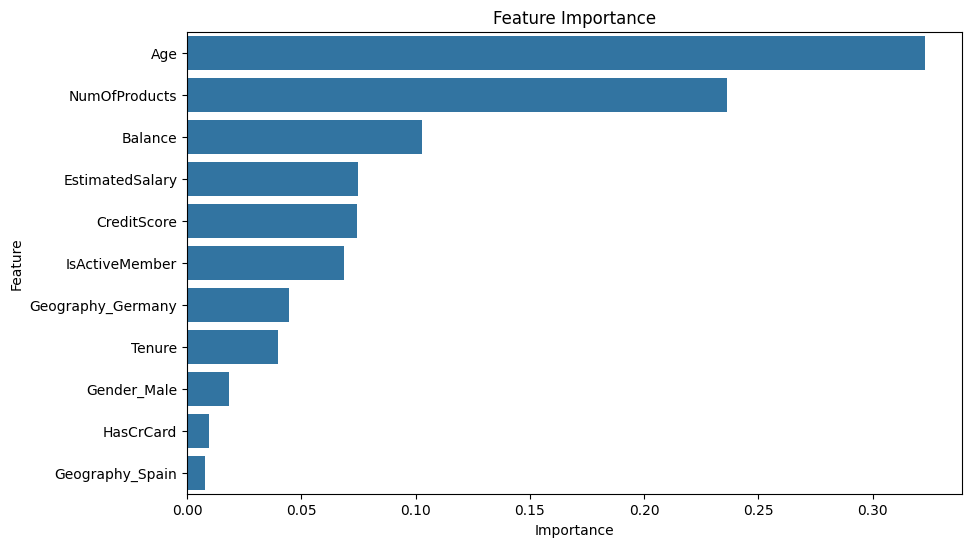

In [84]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [86]:
import joblib

joblib.dump(rf_tuned, "bank_churn_model.pkl")


['bank_churn_model.pkl']

In [87]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']